# 03 — Exploration de la couche Gold : Stress Index Géopolitique × WTI

Lecture du fichier `combined/stress_index/` depuis S3 (LocalStack) pour explorer la table produite par `compute_stress_index.py`.

**Colonnes attendues :**
- **WTI** : Datetime, Open, High, Low, Close, Volume, Volatility_Range, Variation_Pct
- **GDELT lissé** : geo_I_smoothed, geo_B_smoothed, geo_S_smoothed, geo_score_raw_smoothed
- **GDELT brut** : geo_I_sum, geo_B_sum, geo_S_sum, geo_score_raw_sum
- **Métadonnées** : total_event_count, gap_duration_15m, period_main_actor
- **Percentile** : score_pct_7d

In [45]:
import io
import os
import boto3
import pandas as pd
import numpy as np

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Chargement du parquet Gold (dossier Spark) ──
prefix_gold = "combined/stress_index/"
objs_gold = s3.list_objects_v2(Bucket="datalake", Prefix=prefix_gold)
parquet_keys = [o["Key"] for o in objs_gold.get("Contents", []) if o["Key"].endswith(".parquet")]

dfs = []
for key in parquet_keys:
    response = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(response["Body"].read()), engine="pyarrow"))

df_gold = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
df_gold = df_gold.sort_values("Datetime").reset_index(drop=True)

print(f"Shape : {df_gold.shape[0]} lignes × {df_gold.shape[1]} colonnes")
print(f"\nColonnes : {list(df_gold.columns)}")
print(f"\nTypes :\n{df_gold.dtypes}")
print(f"\nPlage temporelle : {df_gold['Datetime'].min()} → {df_gold['Datetime'].max()}")
df_gold.tail(25)

Shape : 848 lignes × 20 colonnes

Colonnes : ['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume', 'Volatility_Range', 'Variation_Pct', 'geo_I_smoothed', 'geo_B_smoothed', 'geo_S_smoothed', 'geo_score_raw_smoothed', 'geo_I_sum', 'geo_B_sum', 'geo_S_sum', 'geo_score_raw_sum', 'total_event_count', 'gap_duration_15m', 'period_main_actor', 'score_pct_7d']

Types :
Datetime                  datetime64[ns]
Open                             float64
High                             float64
Low                              float64
Close                            float64
Volume                             int64
Volatility_Range                 float64
Variation_Pct                    float64
geo_I_smoothed                   float64
geo_B_smoothed                   float64
geo_S_smoothed                   float64
geo_score_raw_smoothed           float64
geo_I_sum                        float64
geo_B_sum                        float64
geo_S_sum                        float64
geo_score_raw_sum    

,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,geo_S_smoothed,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,total_event_count,gap_duration_15m,period_main_actor,score_pct_7d
823,2026-02-27 21:45:00,67.400002,67.410004,67.169998,67.290001,1959,0.24,-0.1336,363.00000,268.303407,258.348808,4836.673517,363.0,268.303407,258.348808,4836.673517,135.0,1,USA,36.21
824,2026-03-01 23:00:00,71.860001,72.550003,71.040001,72.529999,9092,1.51,7.7872,1030.40203,842.033505,808.373639,16896.885272,64224.0,51732.843096,51683.190791,891312.877853,25438.0,197,USA,100.00
825,2026-03-01 23:15:00,72.540001,73.000000,72.070000,72.529999,16195,0.93,0.0000,527.00000,420.357244,448.000746,8101.207385,527.0,420.357244,448.000746,8101.207385,205.0,1,USA,44.23
826,2026-03-01 23:30:00,72.529999,72.910004,72.269997,72.379997,14446,0.64,-0.2068,453.00000,377.765099,373.908239,5846.805395,453.0,377.765099,373.908239,5846.805395,186.0,1,USA,29.93
827,2026-03-01 23:45:00,72.360001,72.480003,71.849998,71.970001,14235,0.63,-0.5664,302.00000,216.716448,198.520011,4125.670007,302.0,216.716448,198.520011,4125.670007,106.0,1,USA,19.02
828,2026-03-02 00:00:00,71.989998,72.129997,71.809998,71.959999,7520,0.32,-0.0139,410.00000,327.159845,329.005179,5597.277556,410.0,327.159845,329.005179,5597.277556,162.0,1,USA,28.35
829,2026-03-02 00:15:00,71.949997,71.989998,71.559998,71.720001,7478,0.43,-0.3335,340.00000,270.120123,291.594209,4860.747822,340.0,270.120123,291.594209,4860.747822,138.0,1,USA,23.68
830,2026-03-02 00:30:00,71.720001,72.050003,71.599998,71.879997,7318,0.45,0.2231,227.50000,206.412455,215.897471,3133.664679,227.5,206.412455,215.897471,3133.664679,100.0,1,RUS,12.73
831,2026-03-02 00:45:00,71.870003,72.110001,71.559998,71.790001,7824,0.55,-0.1252,290.00000,219.055769,230.413747,4024.480188,290.0,219.055769,230.413747,4024.480188,108.0,1,USA,18.38
832,2026-03-02 01:00:00,71.790001,71.830002,70.480003,70.959999,12092,1.35,-1.1562,533.50000,409.220253,425.579139,7913.536381,533.5,409.220253,425.579139,7913.536381,202.0,1,USA,43.04


In [46]:
print(df_gold['period_main_actor'].unique())

['USA' 'SAU' 'CHN' 'RUS' 'CAN' 'MEX' 'PAN']


In [47]:
# ═══════════════════════════════════════════════
# Statistiques descriptives
# ═══════════════════════════════════════════════
print("Valeurs manquantes :")
print(df_gold.isnull().sum())
print(f"\nDoublons sur Datetime : {df_gold.duplicated(subset=['Datetime']).sum()}")
print(f"\nStatistiques numériques :")
df_gold.describe().round(4)

Valeurs manquantes :
Datetime                  0
Open                      0
High                      0
Low                       0
Close                     0
Volume                    0
Volatility_Range          0
Variation_Pct             1
geo_I_smoothed            0
geo_B_smoothed            0
geo_S_smoothed            0
geo_score_raw_smoothed    0
geo_I_sum                 0
geo_B_sum                 0
geo_S_sum                 0
geo_score_raw_sum         0
total_event_count         0
gap_duration_15m          0
period_main_actor         0
score_pct_7d              0
dtype: int64

Doublons sur Datetime : 0

Statistiques numériques :


,Datetime,Open,High,Low,Close,Volume,Volatility_Range,Variation_Pct,geo_I_smoothed,geo_B_smoothed,geo_S_smoothed,geo_score_raw_smoothed,geo_I_sum,geo_B_sum,geo_S_sum,geo_score_raw_sum,total_event_count,gap_duration_15m,score_pct_7d
count,848,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,847.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000,848.0000
mean,2026-02-22 18:13:26.603773440,65.5486,65.6488,65.4431,65.5524,3853.6828,0.2056,0.0154,329.9783,302.3672,278.5986,3750.4529,490.8384,441.6032,412.2401,5778.7363,218.5130,1.6132,30.9175
min,2026-02-16 00:00:00,61.8600,61.9900,61.7600,61.8600,38.0000,0.0300,-2.0011,74.0000,89.3636,83.4033,706.2016,74.0000,89.3636,83.4033,706.2016,43.0000,1.0000,0.0000
25%,2026-02-19 06:56:15,65.0700,65.1675,64.9900,65.0800,676.7500,0.1100,-0.0851,255.5000,245.6884,227.1534,2757.3406,255.5000,246.0488,227.4645,2757.3406,123.0000,1.0000,20.0100
50%,2026-02-23 13:52:30,65.8900,65.9800,65.7900,65.9000,1932.5000,0.1600,0.0151,322.0000,297.8251,274.2884,3566.1092,322.5000,297.8979,274.7510,3567.0191,148.0000,1.0000,28.2750
75%,2026-02-25 20:48:45,66.4000,66.5100,66.2900,66.4100,5351.2500,0.2500,0.1077,387.6250,345.7992,319.3354,4506.1824,388.0000,346.0881,319.6182,4507.1303,172.0000,1.0000,38.8725
max,2026-03-02 04:45:00,72.5400,73.0000,72.2700,72.5300,46560.0000,1.7600,7.7872,1030.4020,842.0335,808.3736,16896.8853,64224.0000,51732.8431,51683.1908,891312.8779,25438.0000,197.0000,100.0000
std,NaN,1.6690,1.6928,1.6378,1.6665,4893.0631,0.1689,0.3523,106.4700,84.8230,79.2664,1472.9188,2694.8288,2287.0280,2224.4613,35376.5611,1126.9679,10.0681,15.7876


---
## Visualisations

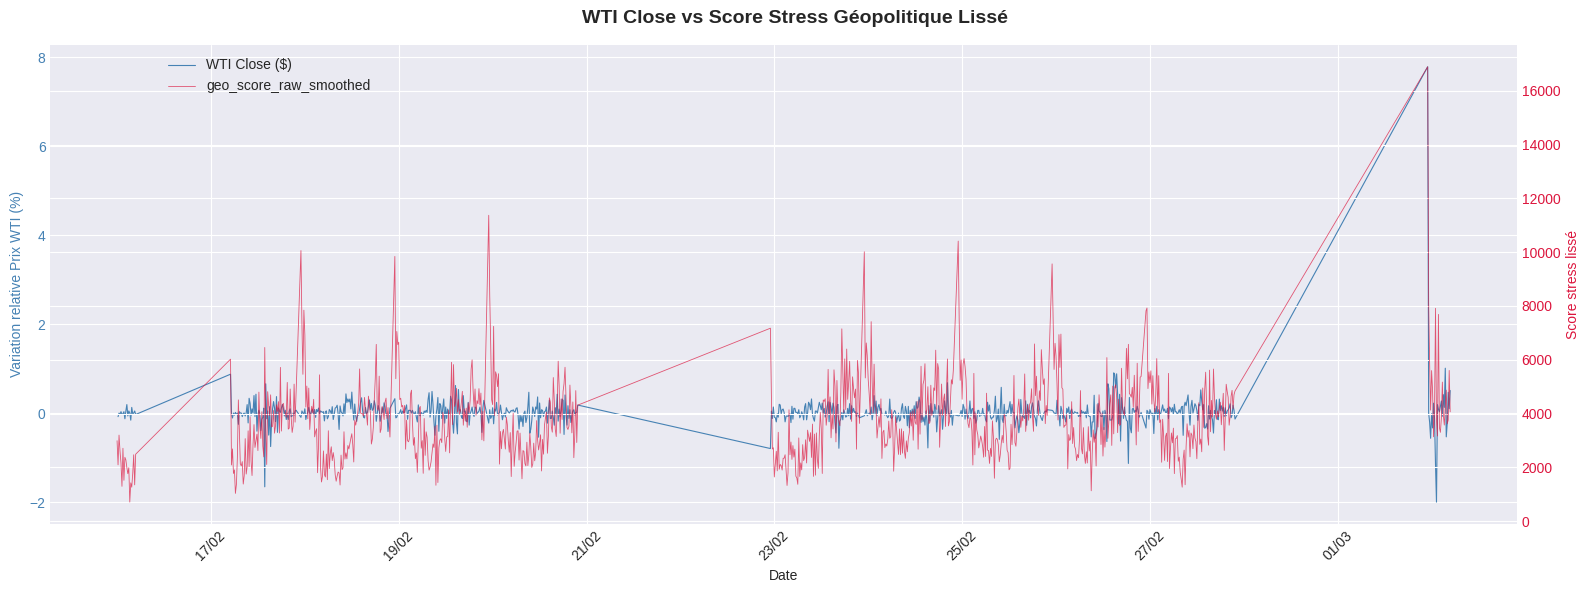

In [55]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8-darkgrid")

# ═══════════════════════════════════════════════
# 1. Prix WTI (Close) + Score Stress lissé (double axe)
# ═══════════════════════════════════════════════
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(df_gold["Datetime"], df_gold["Variation_Pct"], color="steelblue", linewidth=0.8, label="WTI Close ($)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Variation relative Prix WTI (%)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(df_gold["Datetime"], df_gold["geo_score_raw_smoothed"], color="crimson", linewidth=0.6, alpha=0.7, label="geo_score_raw_smoothed")
ax2.set_ylabel("Score stress lissé", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")

fig.suptitle("WTI Close vs Score Stress Géopolitique Lissé", fontweight="bold", fontsize=14)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.92))
plt.tight_layout()
plt.show()

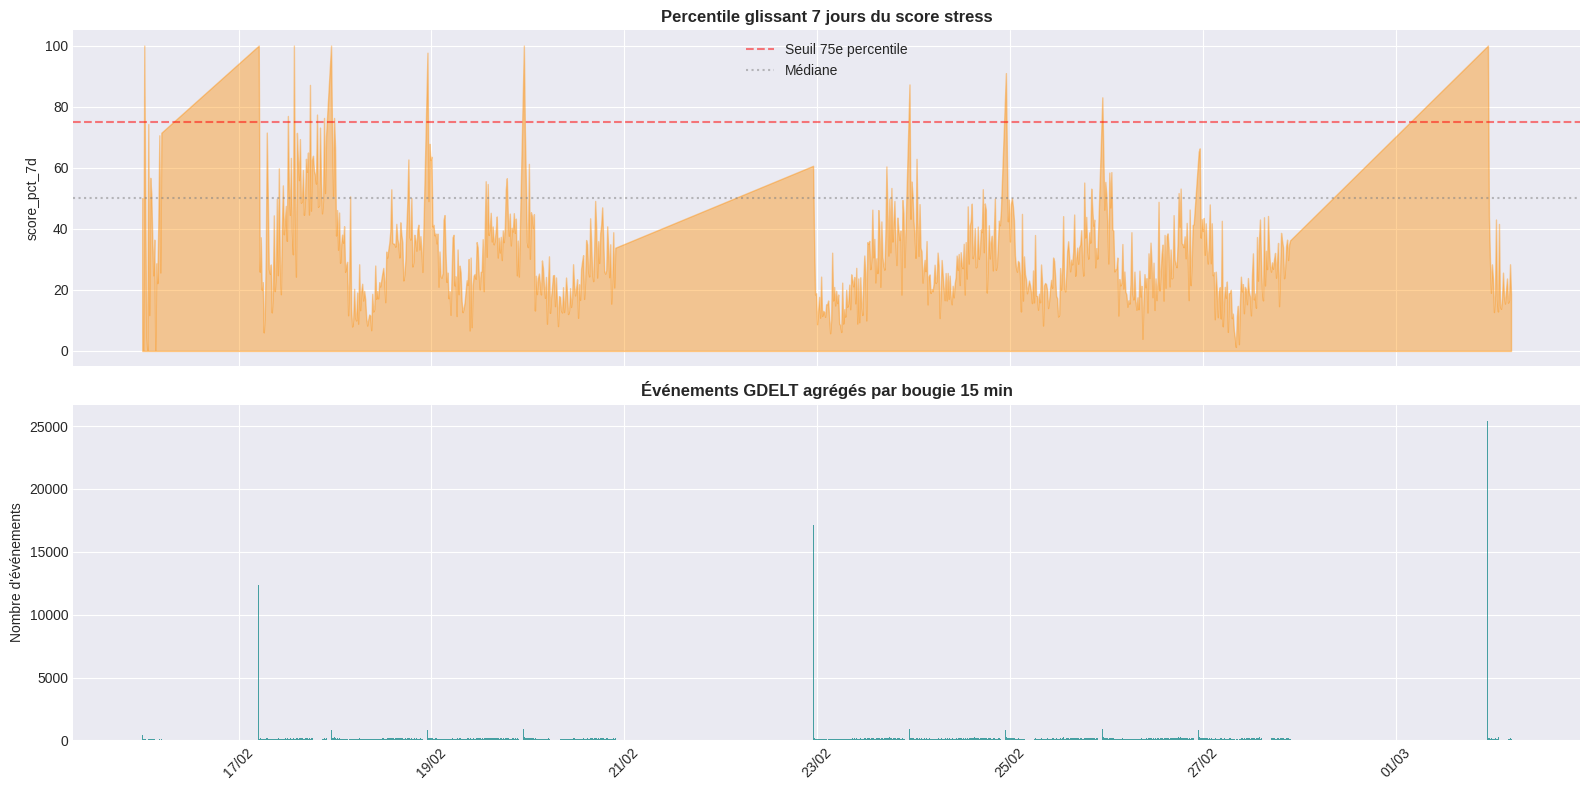

In [49]:
# ═══════════════════════════════════════════════
# 2. Percentile 7 jours (score_pct_7d) + Nombre d'événements
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Percentile 7j
axes[0].fill_between(df_gold["Datetime"], df_gold["score_pct_7d"], alpha=0.4, color="darkorange")
axes[0].axhline(y=75, color="red", linestyle="--", alpha=0.5, label="Seuil 75e percentile")
axes[0].axhline(y=50, color="gray", linestyle=":", alpha=0.5, label="Médiane")
axes[0].set_ylabel("score_pct_7d")
axes[0].set_title("Percentile glissant 7 jours du score stress", fontweight="bold")
axes[0].legend()

# Nombre d'événements
axes[1].bar(df_gold["Datetime"], df_gold["total_event_count"], color="teal", alpha=0.7, width=0.01)
axes[1].set_ylabel("Nombre d'événements")
axes[1].set_title("Événements GDELT agrégés par bougie 15 min", fontweight="bold")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

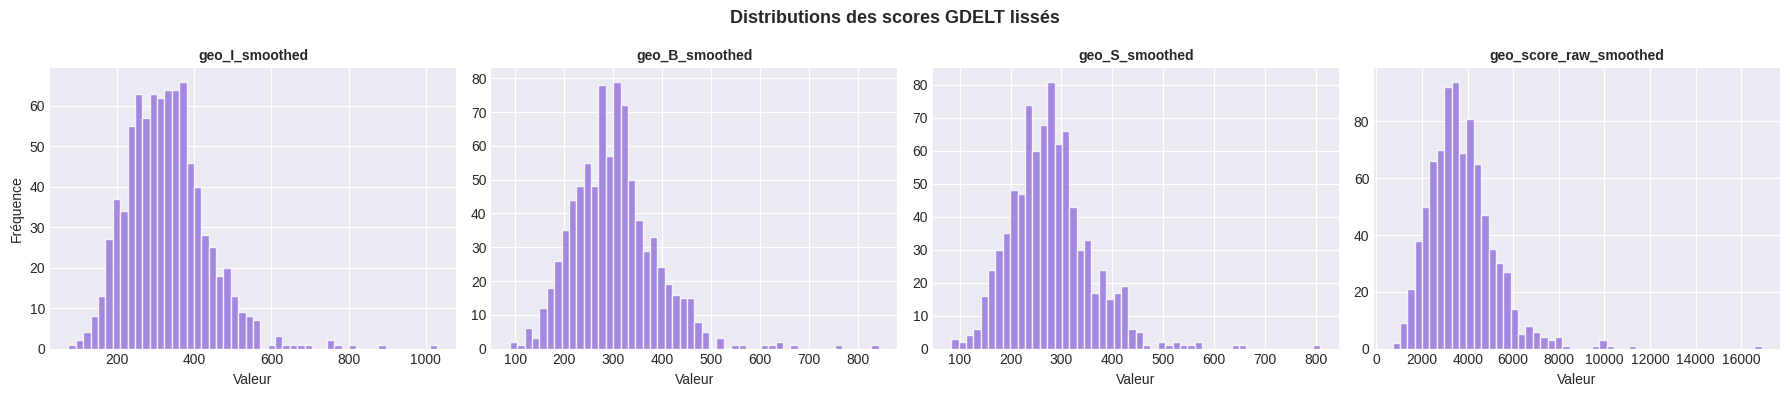

In [50]:
# ═══════════════════════════════════════════════
# 3. Distributions des scores lissés
# ═══════════════════════════════════════════════
score_cols_smoothed = ["geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, col in enumerate(score_cols_smoothed):
    axes[i].hist(df_gold[col].dropna(), bins=50, color="mediumpurple", alpha=0.8, edgecolor="white")
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Fréquence" if i == 0 else "")

plt.suptitle("Distributions des scores GDELT lissés", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

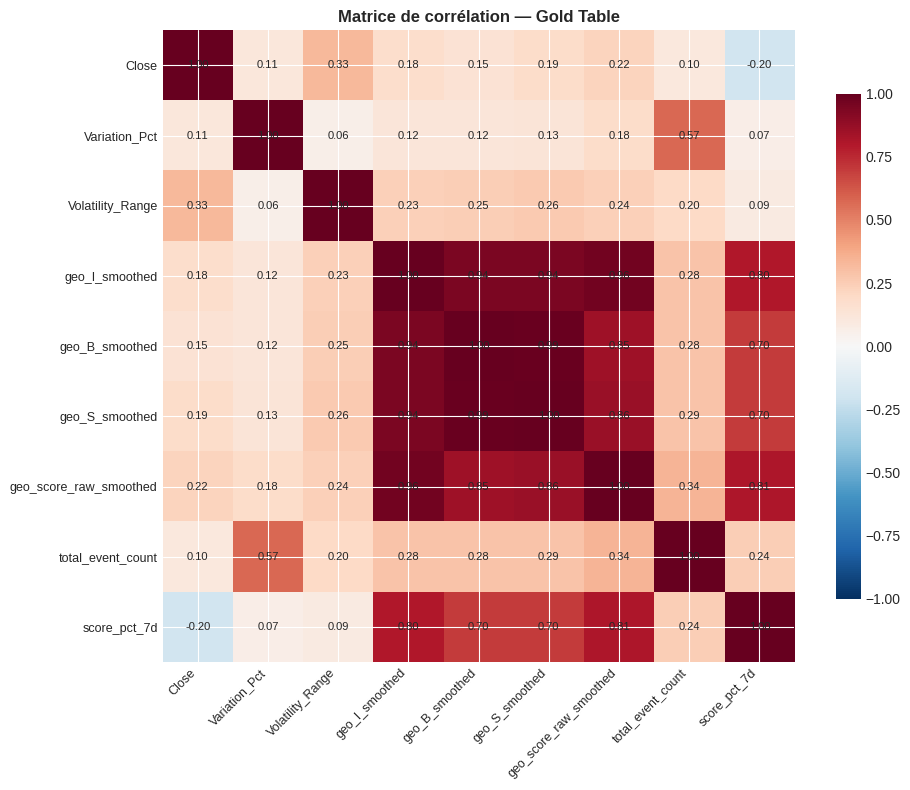

In [51]:
# ═══════════════════════════════════════════════
# 4. Matrice de corrélation
# ═══════════════════════════════════════════════
corr_cols = [
    "Close", "Variation_Pct", "Volatility_Range",
    "geo_I_smoothed", "geo_B_smoothed", "geo_S_smoothed", "geo_score_raw_smoothed",
    "total_event_count", "score_pct_7d",
]
corr_matrix = df_gold[corr_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Annotations
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.title("Matrice de corrélation — Gold Table", fontweight="bold")
plt.tight_layout()
plt.show()

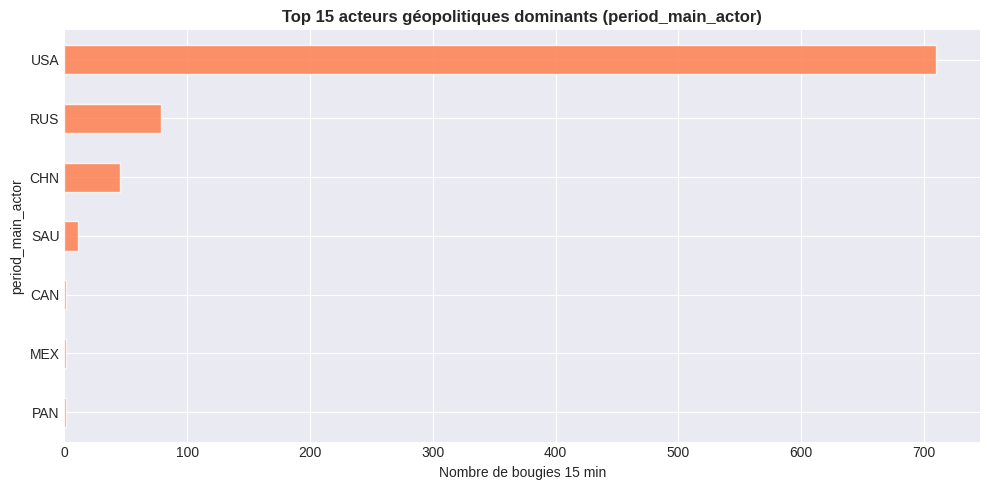

In [52]:
# ═══════════════════════════════════════════════
# 5. Top acteurs géopolitiques (period_main_actor)
# ═══════════════════════════════════════════════
top_actors = df_gold["period_main_actor"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_actors.plot(kind="barh", color="coral", alpha=0.85, edgecolor="white", ax=ax)
ax.set_title("Top 15 acteurs géopolitiques dominants (period_main_actor)", fontweight="bold")
ax.set_xlabel("Nombre de bougies 15 min")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

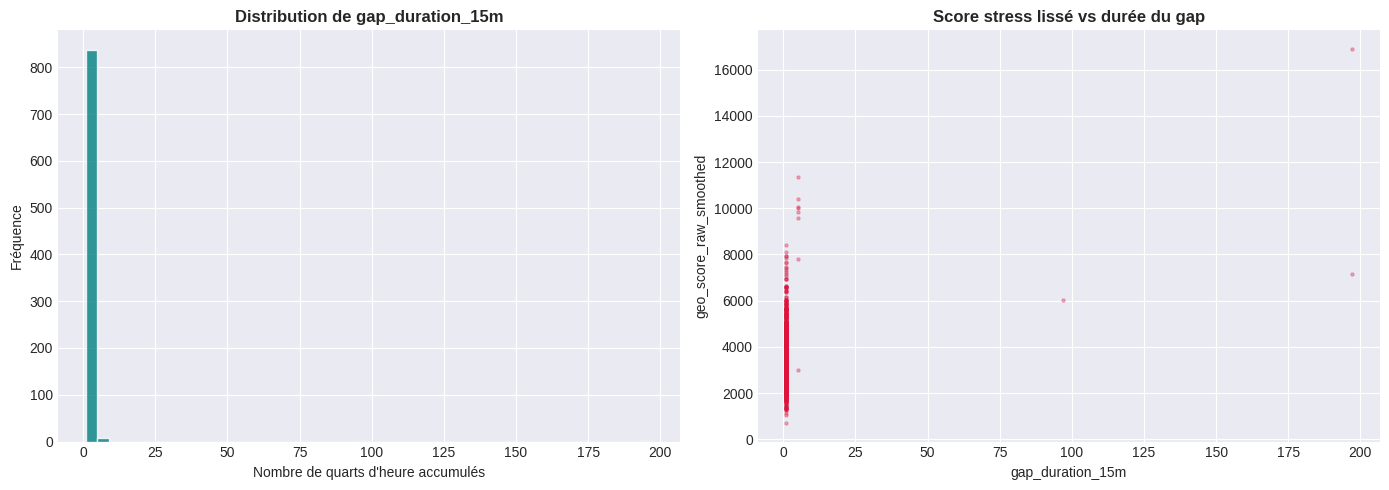

In [53]:
# ═══════════════════════════════════════════════
# 6. Gap duration : analyse du forward mapping
# ═══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution de gap_duration_15m
axes[0].hist(df_gold["gap_duration_15m"].dropna(), bins=50, color="teal", alpha=0.8, edgecolor="white")
axes[0].set_title("Distribution de gap_duration_15m", fontweight="bold")
axes[0].set_xlabel("Nombre de quarts d'heure accumulés")
axes[0].set_ylabel("Fréquence")

# Score stress vs gap_duration (les réouvertures après longs gaps sont-elles plus stressées ?)
axes[1].scatter(df_gold["gap_duration_15m"], df_gold["geo_score_raw_smoothed"],
               alpha=0.3, s=5, color="crimson")
axes[1].set_title("Score stress lissé vs durée du gap", fontweight="bold")
axes[1].set_xlabel("gap_duration_15m")
axes[1].set_ylabel("geo_score_raw_smoothed")

plt.tight_layout()
plt.show()

In [54]:
# ═══════════════════════════════════════════════
# 7. Aperçu des lignes avec le score stress le plus élevé
# ═══════════════════════════════════════════════
top_stress = df_gold.nlargest(20, "geo_score_raw_smoothed")[
    ["Datetime", "Close", "Variation_Pct", "geo_score_raw_smoothed",
     "score_pct_7d", "total_event_count", "period_main_actor", "gap_duration_15m"]
]
print("Top 20 bougies avec le score stress lissé le plus élevé :")
top_stress

Top 20 bougies avec le score stress lissé le plus élevé :


,Datetime,Close,Variation_Pct,geo_score_raw_smoothed,score_pct_7d,total_event_count,period_main_actor,gap_duration_15m
824,2026-03-01 23:00:00,72.529999,7.7872,16896.885272,100.00,25438.0,USA,197
272,2026-02-19 23:00:00,66.519997,-0.2250,11372.618134,100.00,942.0,USA,5
548,2026-02-24 23:00:00,66.040001,-0.0605,10413.125962,91.00,859.0,RUS,5
88,2026-02-17 23:00:00,62.160000,-0.0964,10060.332492,100.00,830.0,USA,5
456,2026-02-23 23:00:00,66.250000,-0.0603,10016.095042,87.28,889.0,USA,5
180,2026-02-18 23:00:00,65.150002,0.3234,9842.636131,97.67,850.0,USA,5
640,2026-02-25 23:00:00,65.610001,0.0610,9564.678591,83.05,881.0,USA,5
273,2026-02-19 23:15:00,66.570000,0.0752,8414.260536,72.26,244.0,USA,1
825,2026-03-01 23:15:00,72.529999,0.0000,8101.207385,44.23,205.0,USA,1
733,2026-02-26 23:15:00,65.290001,0.0613,7925.086565,66.35,283.0,USA,1
